In [19]:
import matplotlib.pyplot as plt
import numpy as np
import slave_rotor_atomic
import slave_rotor_MF
import slave_rotor_isotropic
import importlib
import mpl_style
importlib.reload(mpl_style)
panel_figsize_for, PANEL_FIGSIZE, color_of = mpl_style.apply_style(single_col_width_in=7.06, text_height_in=9.30)

In [10]:
Dat = {}
Dat[('inf',0.25)] = out
Dat

{('inf', 0.25): [0.31000176315931655,
  0.769859810662232,
  0.6729846591480696,
  0.6008954431667868,
  0.5269110813123854,
  0.44365252063626764,
  0.4000709291410364,
  0.2980207408727891,
  0.1691728927900953,
  0.11175127996131028,
  9.67241843429741e-05,
  3.159129177505215e-14,
  2.2185505538431197e-15,
  8.427430482368172e-16,
  6.197084863777953e-16,
  3.60661439748624e-16,
  1.800179769042464e-16,
  1.6318530360250458e-16,
  1.0305360033414227e-16,
  9.726166853243412e-17]}

In [17]:
Us = np.linspace(0,6,num=20)
SHARED = {
    'alpha':     1.0,
    'N':         4,
    'beta':      beta,
    'density':   density,
    'U':         None,
    't_perp':    None,
    'K_init':    2.0,
    'M_trunc':   10,
    'mixing':    0.5,
    'iterations':1200,
    'tol':       1e-8,
    'h_window':  25.0,
    'eps_window':25.0,
    'n_coarse':  51,
    'n_eigs':    20,
    'verbose':   1,
}
t0_table = slave_rotor_isotropic._T0_density_table(
        t_perp=SHARED['t_perp'],
        density_grid=np.linspace(0.0, 1.0, 2001),
        N_e=4000,
    )
SHARED['t0_table'] = t0_table
Dat = {}
for density in [0.25,0.50]:
    for beta in [20.,200.,2000.,'inf']:
        Dat[(beta,density)] = []
        for U in Us:
            SHARED['U'] = U
            SHARED['beta'] = beta
            SHARED['density'] = density
            results = slave_rotor_isotropic.solve_isotropic_MF(SHARED)
            Dat[(beta,density)].append(results['Z'])

  iter    1: h=+2.880064e-03  eps=+4.833463e-01  K=+2.000000e+00  K_raw=+1.453310e+00  K_new=+1.726655e+00  Q=-9.800231e-01  Z=0.9604  I0=+2.500000e-01  I1=-1.853668e-01  mu_eff=-5.002536e-01  delta=inf
  iter    2: h=+2.690374e-03  eps=+4.809507e-01  K=+1.726655e+00  K_raw=+1.449809e+00  K_new=+1.588232e+00  Q=-9.777706e-01  Z=0.9560  I0=+2.500000e-01  I1=-1.853463e-01  mu_eff=-5.002538e-01  delta=1.41e-01
  iter    3: h=+2.595054e-03  eps=+4.794471e-01  K=+1.588232e+00  K_raw=+1.447569e+00  K_new=+1.517901e+00  Q=-9.763299e-01  Z=0.9532  I0=+2.500000e-01  I1=-1.853330e-01  mu_eff=-5.002539e-01  delta=7.19e-02
  iter    4: h=+2.546747e-03  eps=+4.785850e-01  K=+1.517901e+00  K_raw=+1.446273e+00  K_new=+1.482087e+00  Q=-9.754964e-01  Z=0.9516  I0=+2.500000e-01  I1=-1.853253e-01  mu_eff=-5.002540e-01  delta=3.67e-02
  iter    5: h=+2.522169e-03  eps=+4.781165e-01  K=+1.482087e+00  K_raw=+1.445566e+00  K_new=+1.463826e+00  Q=-9.750414e-01  Z=0.9507  I0=+2.500000e-01  I1=-1.853211e-01  mu

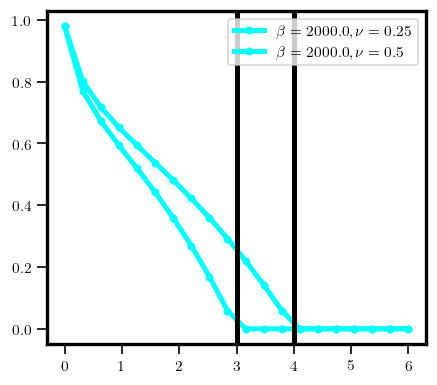

In [27]:
col = {20:'red',200:'orange',2000:'cyan','inf':'blue'}
fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)
for density in [0.25,0.50]:
    for beta in [2000.]:
        plt.plot(Us,Dat[beta,density],'.-',label = f'$\\beta = {beta},\\nu={density}$',c = col[beta])
plt.axvline(x=3,ymin=0,ymax=1,c='k')
plt.axvline(x=4,ymin=0,ymax=1,c='k')
plt.legend()

In [96]:
beta = 1000.
SHARED = {
    'alpha':     1.0,
    'N':         6,
    'beta':      beta,
    'density':   None,
    'U':         20,
    't_perp':    0.25,
    'K_init':    2.0,
    'M_trunc':   10,
    'mixing':    0.5,
    'iterations':1200,
    'tol':       1e-8,
    'h_window':  25.0,
    'eps_window':25.0,
    'n_coarse':  51,
    'n_eigs':    20,
    'verbose':   1,
}
def _near_int(center, delta=0.03, n_extra=4):
    """A few extra points clustered within `delta` of a commensurate filling."""
    return np.linspace(center - delta, center + delta, n_extra + 1)

n_per = np.unique(np.concatenate([
    np.linspace(0.02, 0.1,  3),                                        # dilute  (below n_tot=1)
    _near_int(1./6,delta = 0.015,n_extra = 5),                          # near  n_tot = 1
    np.linspace(0.22, 0.28,  3),                                        # between n_tot = 1 and 2
    _near_int(2./6,delta = 0.015,n_extra = 5),                          # near  n_tot = 2  (half-filling)
    np.linspace(0.38, 0.45,  3),                                        # between n_tot = 2 and 3
    _near_int(0.5,delta = 0.015,n_extra = 5),                          # near  n_tot = 3
    np.linspace(0.55, 0.62,  3),                                        # dense   (above n_tot=3)
    _near_int(4./6,delta = 0.015,n_extra = 5),                          # near  n_tot = 3
    np.linspace(0.70, 0.80,  3),    
    _near_int(5./6,delta = 0.015,n_extra = 5),                          # near  n_tot = 3
    np.linspace(0.990, 0.98,  3),    
]))

t0_table = slave_rotor_isotropic._T0_density_table(
        t_perp=SHARED['t_perp'],
        density_grid=n_per,
        N_e=4000,
    )
SHARED['t0_table'] = t0_table
Dat = {}
Dat[beta] = {}
Dat[beta]['Z'] = []
Dat[beta]['eps_0'] = []
Dat[beta]['fluct'] = []
for density in n_per:
    SHARED['density'] = density
    results = slave_rotor_isotropic.solve_isotropic_MF(SHARED)
    Dat[beta]['Z'].append(results['Z'])
    Dat[beta]['eps_0'].append(results['eps_0'])
    Dat[beta]['fluct'].append(results['Lsq'] - results['L']**2)

  iter    1: h=+5.228589e+01  eps=+5.261809e+01  K=+2.000000e+00  K_raw=+2.184746e-01  K_new=+1.109237e+00  Q=-3.802788e-01  Z=0.1446  I0=+2.000000e-02  I1=-4.787597e-02  mu_eff=-2.297136e+00  delta=inf
  iter    2: h=+5.128862e+01  eps=+5.157684e+01  K=+1.109237e+00  K_raw=+2.034834e-01  K_new=+6.563603e-01  Q=-3.542085e-01  Z=0.1255  I0=+2.000000e-02  I1=-4.787278e-02  mu_eff=-2.297225e+00  delta=2.49e+00
  iter    3: h=+5.076583e+01  eps=+5.103433e+01  K=+6.563603e-01  K_raw=+1.963891e-01  K_new=+4.263747e-01  Q=-3.418734e-01  Z=0.1169  I0=+2.000000e-02  I1=-4.787083e-02  mu_eff=-2.297281e+00  delta=1.30e+00
  iter    4: h=+5.049813e+01  eps=+5.075722e+01  K=+4.263747e-01  K_raw=+1.929111e-01  K_new=+3.096429e-01  Q=-3.358265e-01  Z=0.1128  I0=+2.000000e-02  I1=-4.786974e-02  mu_eff=-2.297312e+00  delta=6.62e-01
  iter    5: h=+5.036191e+01  eps=+5.061637e+01  K=+3.096429e-01  K_raw=+1.911755e-01  K_new=+2.504092e-01  Q=-3.328092e-01  Z=0.1108  I0=+2.000000e-02  I1=-4.786915e-02  mu

KeyboardInterrupt: 

In [97]:
len(Dat[1000.]['eps_0'])

45

(0.0, 6.0)

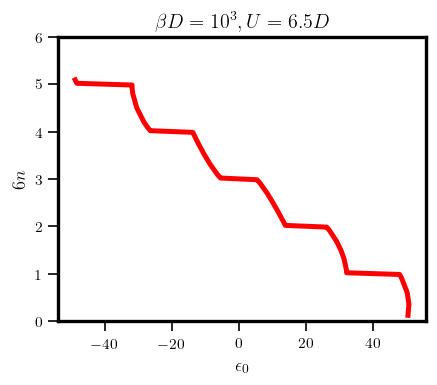

In [98]:
fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)
plt.plot(Dat[1000.]['eps_0'],n_per[:45]*6,c = 'r')
#plt.plot(Dat[2000.]['eps_0'],np.array(Dat[2000.]['fluct']),c = 'b')
#plt.xlim([-16,+16])
plt.title(f'$\\beta D = 10^3, U = 6.5 D $')
plt.xlabel('$\epsilon_0$')
plt.ylabel('$6n$')
plt.ylim([0,6])
#plt.savefig('SU6_Antoines_Fig7_confirm.png')
#plt.plot(n_per*4,Dat[2000.]['Z'],c = 'b')